# Premikanje robota in izvajanje trajektorij

1. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.

2. Izrišite zajeto trajektorijo.

3. Naredite robota ponovno togega - na varen način - in izvedite posneto trajektorijo v prostoru sklepov na pribl. 100 Hz. Uporabite metodo `JPath` in `robot.GoTo_q` v zanki. **Bodite pozorni, da skoki v referenčnih vrednostih niso preveliki!**

4. Trajektorijo zapišite z uporabo DMP-jev - kodirajte v DMP. 

5. Trajektorijo dekodirajte iz DMP-jev in jo narišite na isti plot kot osnovno, zajeto trajektorijo. **Pozor! robot ima 7 sklepov!**

6. Narišite jedrne funkcije in uteži. 

7. Dekodirajte trajektorijo iz DMPja in jo izvedite z uporabo `robot.GoTo_q` v zanki.

8. Primerjajte trajektoriji iz obeh izvedb, ali je kaj razlike?

9. Spremenite hitrost izvajanja s spremembo parametrov DMP-ja - parameter za čas \tau. Nastavite, da se DMP izvede 2x hitreje in 2x počasneje.

10. Na nov plot narišite osnovno, pohitreno in upočasnjeno trajektorijo. Kako izgledajo.

11. Pogovorite se z asistenti, kako bi isto spremembo hitrosti in izvedbo naredil brez uporabe DMPja.

12. Posnemite DMP v kartezijskem prostoru - podajte vektor pozicij namesto sklepov. Orientacija naj bo konstantna in je ne zapisujte v DMP. Pogovorite se kaj je problem zapisa orientacij.

13. Narišite x-y-z trajektorije na plot. Izvedite ta gib z robotom z uporabo CPath.

14. Malo spremenite cilj (g) DMPja in dekodirajte trajektorijo. Narišite jo na isti plot.

15. Izvedite ta nov gib z uporabo CPath.

16. Ponovite kodiranje istega giba, kjer podate še parameter a_z. Ponovite koraka 14. in 15. Vse narišite na isti graf.

17. Poskusite spremeniti tudi čas izvajanja ter potem hkrati čas in cilj. Narišite te trajektorije ter jih tudi izvedite.

18. Narišite družino trajektorij, kjer se g spreminja, npr po 5 cm, od 0 do 30 cm.

19. Izvedite te trajektorije.



**Inicializacija robotov**

In [147]:
import rospy
import inspect
from robotblockset.ros.grippers_ros import PandaGripper
from importlib import reload
import example_data_recorder
#reload(example_data_recorder)
from utils import SoftSetJointCompliance
ns = "pingvin_1"
rospy.init_node(ns)
from robotblockset.ros.franka import panda_ros
r = panda_ros(ns=ns, control_strategy="JointImpedance", init_node=False)
g = PandaGripper(namespace=ns,robot=r)

Panda::Initialized
Panda:Gripper:ROS:Created


**1. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.**

Spodnji funkciji za snemanje stanja robota, dodajte še zapisovanje lege vrha

In [2]:
r.SetJointCompliant() # Ojačanja v kontrolerju nastavi na 0, robot bo kompenziral le gravitacijo

:Joint compliance changed 
Stiff:[0. 0. 0. 0. 0. 0. 0.]
Damp:[0. 0. 0. 0. 0. 0. 0.]


In [ ]:
import numpy as np
import time
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency
    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N   

In [ ]:
r._semaphore.release


In [ ]:
# Koda za zajem trajektorije
from utils import pip

time.sleep(1)
print ("start")
pip();
# vzorčimo 3 sekunde pri 100Hz
tt, qt, dqt, i, N = record_robot_state(r,100,3)
pip();
print ("stop")

**2. Izrišite zajeto trajektorijo.**

In [ ]:
from robotblockset.graphics import plotjtraj
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(9, 6))
fig.suptitle('Joint trajectories')
plotjtraj(tt, qt, dqt, ax=ax);
plotjtraj(tt, qt+0.01, dqt, ax=ax, linestyle="--");


**3. Naredite robota ponovno togega - na varen način - in izvedite posneto trajektorijo v prostoru sklepov na pribl. 100 Hz. Uporabite metodo `JPath` in `robot.GoTo_q` v zanki. Bodite pozorni, da skoki v referenčnih vrednostih niso preveliki!**

In [ ]:
import utils
from utils import SoftSetJointCompliance

r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)



***PRED IZVEDBO TRAJEKTORIJE UPORABITE JMOVE V PRVO POZICIJO!!!***

In [ ]:

# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    r.GoTo_q(q,qdot,np.zeros(7),0)
    # time.sleep(1/100.)
    time.sleep(tm[0])

**4. Trajektorijo zapišite z uporabo DMP-jev (glej DMP.ipynb).**

In [ ]:
from dmp import DMP

# Za pomoč poglejte zvezek DMP
d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
d1 =DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
d2 =DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)

print(d1)

d1.a_x = 1
d2.a_x = 4

#d1.b_z = 1
#d2.b_z = 4

#d1.a_z = 1
#d2.a_z = 4

trj_dec,t_dec=d.decode()
trj_dec1,t_dec1=d1.decode()
trj_dec2,t_dec2=d2.decode()



plotjtraj(qt=trj_dec, t=t_dec);


In [ ]:
plotjtraj(qt=trj_dec1, t=t_dec1);

In [ ]:
plotjtraj(qt=trj_dec2, t=t_dec2);

In [ ]:
d.goal

**5. Trajektorijo dekodirajte iz DMP-jev in jo narišite na isti plot kot osnovno, zajeto trajektorijo. Pozor! robot ima 7 sklepov!**

Predebatirajte sliko z asistentom

**6. Narišite jedrne funkcije in uteži za en sklep.**

Najprej narišite fazo, nato narišite jedrne funkcije.
Narišite tudi jedrne funkcije za (en) poljuben sklep (pomnožene z utežmi).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x = np.exp(-d.a_x * d._time_vec / d.tau)
psi = np.zeros((x.size, d.num_weights))
i = 0
for val in x:
    psi[i] = np.exp(- np.square(val-d.c) /
                 (np.multiply(d.sigma, 2)))
    i+=1

plt.plot(psi)
plt.show()


**7. Ponovno dekodirajte trajektorijo iz DMPja in jo izvedite z uporabo `robot.GoTo_q` v zanki.**

In [ ]:
# Move slowly to the first configuration
r.JMove(trj_dec[0],5)
pip();
for q in trj_dec: 
    # Call the GoTo_q function
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(1/100.)

**8. Primerjajte trajektoriji iz obeh izvedb, ali je kaj razlike?**

**9. Spremenite hitrost izvajanja s spremembo parametrov DMP-ja - parameter za čas \tau. Nastavite, da se DMP izvede 2x hitreje in 2x počasneje.**

In [ ]:
# Move slowly to the first configuration
r.JMove(trj_dec[0],5)
pip();
for q in trj_dec: 
    # Call the GoTo_q function
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(1/100.)

**10. Na nov plot narišite osnovno, pohitreno in upočasnjeno trajektorijo. Kako izgledajo.**

In [ ]:
# Dekodiraj časovno spremenjen DMP

fig, ax = plt.subplots(3, 1, figsize=(9, 6))
fig.suptitle('Joint trajectories')
plotjtraj(tt, qt, dqt, ax=ax);
#plotjtraj(t=, qt=, ax=ax, linestyle="--");
plotjtraj(qt=trj_dec1, t=t_dec1, ax=ax, linestyle="--");
plotjtraj(qt=trj_dec2, t=t_dec2, ax=ax, linestyle="--");

**11. Pogovorite se z asistenti, kako bi isto spremembo hitrosti in izvedbo naredil brez uporabe DMPja.**

**12. Znova posnemite DMP v kartezijskem prostoru - zapišite samo pozicije. Orientacija naj bo konstantna in je ne zapisujte v DMP. Pogovorite se kaj je problem zapisa orientacij.**  
Pogovorite se z asistentom kakšno obliko naj ima nova trajektorija.

In [19]:
#
import numpy as np
import time
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency

    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))
    xt = np.zeros((N, 7))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot
            xt[i, :] = r.x.copy()

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N, xt 

In [3]:
import time
import numpy as np
from utils import pip

def record_robot_cartesian(robot, frequency, duration):
    interval = 1.0 / frequency
    N = int(frequency * duration)

    tt = np.zeros(N)
    xt = np.zeros((N, 7))
    dxt = np.zeros((N, 7))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    last_update = start_time - interval

    while time.monotonic() <= end_time and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            pos = robot.x.copy()
            tt[i] = t - start_time
            xt[i, :] = pos

            if i > 0:
                dxt[i, :] = (xt[i, :] - xt[i-1, :]) / interval

            last_update = t
            i += 1

    return tt, xt, dxt, i, N

In [20]:
# Koda za zajem 
# Koda za zajem trajektorije
time.sleep(1)
print("start")
#tt, xt, dxt, i, N = record_robot_cartesian(r, 100, 3)
tt, qt, dqt, i, N, xt  = record_robot_state(r, 100, 3)
print("stop")

start
stop


In [ ]:
#print(type(tt), tt.shape)
#print(type(xt), xt.shape)
#print(tt[:5])
#print(xt[:5])
xt1=xt.copy()
xt1 = np.concatenate((xt, np.tile([0, 0, 0, 1], (N, 1))), axis=1)
print(xt1[:5])


In [9]:
print("tt:", type(tt), tt.shape)
print("xt1:", type(xt), xt.shape)
print("first row xt:", xt[0])

tt: <class 'numpy.ndarray'> (300,)
xt1: <class 'numpy.ndarray'> (300, 7)
first row xt: [ 0.5276356   0.1258513   0.53388987 -0.00984932 -0.97711522 -0.15539057
 -0.14492275]


In [24]:
import inspect
sig = inspect.signature(plotctraj)
print(sig)

(t: numpy.ndarray, xt: numpy.ndarray, *args: numpy.ndarray, grid: bool = True, fig_num: str = 'Cartesian trajectory', ax: list = None, **kwargs) -> list


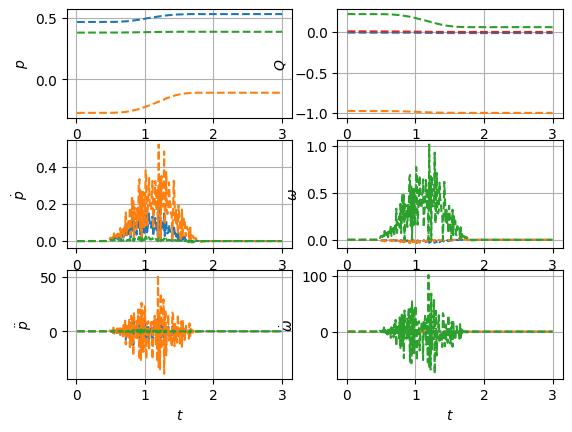

In [31]:
import matplotlib.pyplot as plt
from robotblockset.graphics import plotctraj
from robotblockset.graphics import plotjtraj

#fig, ax = plt.subplots(3, 1, figsize=(9, 6))
#fig.suptitle("Cartesian trajectories")

res11= plotctraj(t=tt, xt=xt, linestyle="--")

#plt.tight_layout()
plt.show()

In [43]:
xt1 = np.zeros((N,7))
xt1[:,0:3]= xt[:,0:3].copy()
xt1[:,3:7]= xt[1,3:7].copy()
print(xt1[:5])

[[ 0.46616528 -0.27286492  0.37975487 -0.00741736 -0.97512728  0.22137607
   0.00802494]
 [ 0.46616352 -0.27286873  0.3797517  -0.00741736 -0.97512728  0.22137607
   0.00802494]
 [ 0.4661618  -0.2728676   0.3797486  -0.00741736 -0.97512728  0.22137607
   0.00802494]
 [ 0.46616296 -0.27286836  0.37975191 -0.00741736 -0.97512728  0.22137607
   0.00802494]
 [ 0.4661608  -0.27286902  0.37975067 -0.00741736 -0.97512728  0.22137607
   0.00802494]]


In [148]:
# Zakodiraj DMP s katezijsko trajektorijo, pri tem uporabite samo pozicije (x, y, z)
# POZOR! UPORABI COPY()
import numpy as np
x = xt1.copy()                
t = tt.flatten().copy()      
from dmp import DMP
dmp = DMP(
    pos_data=x.copy(),     
    time=t.copy(),            
    num_weights=50
)


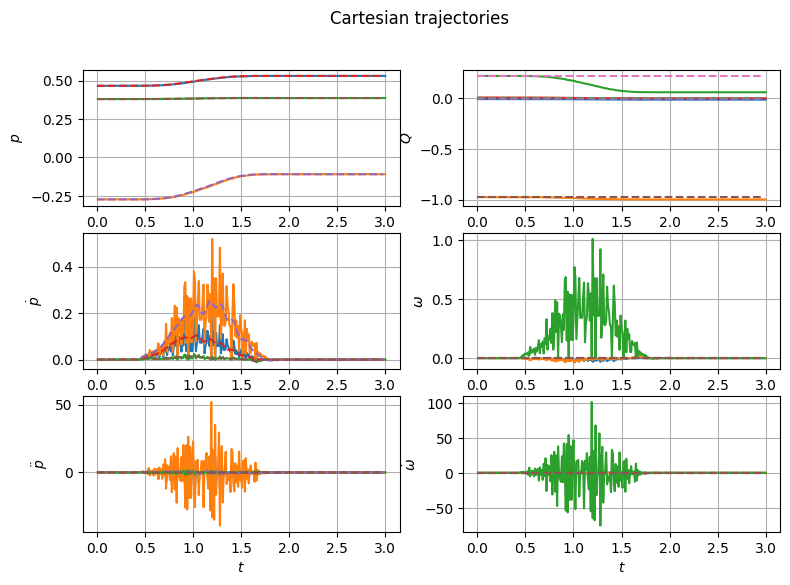

In [54]:
# Deokdiraj DMP v kartezijsko trajektorijo in jo izriši
# Bodi pozoren na vhodni parameter xt v funkciji plotctraj()
import matplotlib.pyplot as plt
from robotblockset.graphics import plotctraj
import numpy as np

traj_dec, t_dec = dmp.decode()
xt_dec = traj_dec.copy()
xt_orig = xt.copy()
t_orig = tt.flatten().copy()
t_dec = np.array(t_dec)

fig, ax = plt.subplots(3, 2, figsize=(9, 6))
fig.suptitle("Cartesian trajectories")

plotctraj(t=t_orig, xt=xt_orig, ax=ax)
plotctraj(t=t_dec, xt=xt_dec, ax=ax, linestyle="--")

plt.show()


**13. Narišite x-y-z trajektorije na plot. Izvedite ta gib z robotom z uporabo CPath.**

In [56]:
import matplotlib.pyplot as plt
from robotblockset.graphics import plotctraj
import numpy as np

traj_dec, t_dec = dmp.decode()
xt_dec = traj_dec.copy()
t_dec = np.array(t_dec)  # ⚠️ pretvorba v 1D numpy array

#fig, ax = plt.subplots(3, 1, figsize=(8, 6))
#fig.suptitle("TCP trajectories: x, y, z")

plotctraj(t=t_dec, xt=xt_dec, ax=ax, linestyle="--")

plt.show()

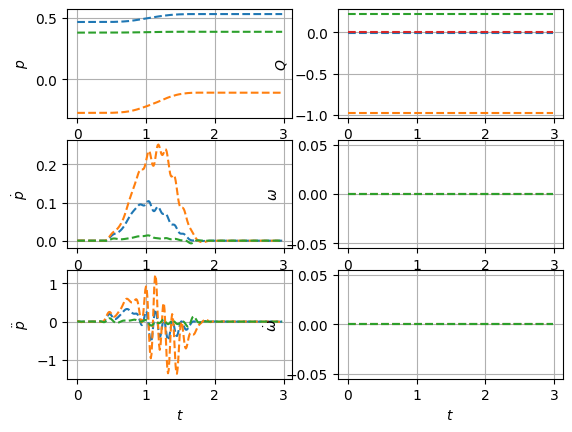

In [58]:
import matplotlib.pyplot as plt
from robotblockset.graphics import plotctraj

#fig, ax = plt.subplots(3, 1, figsize=(9, 6))
#fig.suptitle("Cartesian trajectories")

res11= plotctraj(t=t_dec, xt=xt_dec, linestyle="--")

#plt.tight_layout()
plt.show()

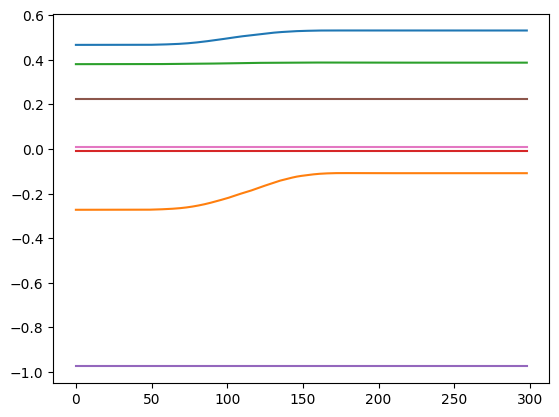

In [57]:
plt.plot(traj_dec)

In [76]:
import inspect
#from robotblockset.robots import robot
#sig = inspect.signature(robot.CPath)
sig = inspect.signature(r.CPath)
print(sig)

(path, t, wait=None, task_space=None, added_FT=None, state='Commanded', asynchronous=False, **kwargs)


In [111]:
import utils
from utils import SoftSetJointCompliance

r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)




:Joint compliance changed 
Stiff:[ 1200.0000  1200.0000  1200.0000  1200.0000  0.0000  0.0000  0.0000]
Damp:[25 25 25 25 10 10 10]


In [ ]:
# Move slowly to the first configuration
r.CMove(xt_dec[0],5)

In [79]:

r.CPath(path=xt_dec,t=t_dec)




0

**14. Malo spremenite cilj (g) DMPja in dekodirajte trajektorijo. Narišite jo na isti plot.**

In [83]:
dmp.goal

array([ 0.5306, -0.1089,  0.5000, -0.0074, -0.9751,  0.2214,  0.0080])

In [87]:
dmp.goal[2]=0.5

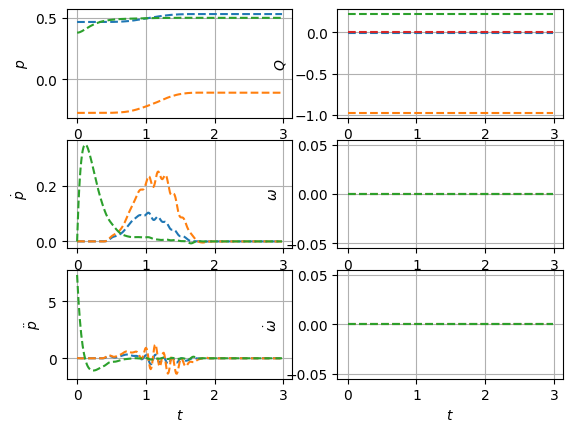

In [88]:
import matplotlib.pyplot as plt
from robotblockset.graphics import plotctraj
import numpy as np

traj_dec2, t_dec2 = dmp.decode()
xt_dec2 = traj_dec2.copy()
t_dec2 = np.array(t_dec2)  # ⚠️ pretvorba v 1D numpy array

#fig, ax = plt.subplots(3, 1, figsize=(8, 6))
#fig.suptitle("TCP trajectories: x, y, z")

plotctraj(t=t_dec2, xt=xt_dec2, linestyle="--")

plt.show()

In [90]:
r.CMove(xt_dec[0],5)
r.CPath(path=xt_dec,t=t_dec)
r.CMove(xt_dec2[0],5)
r.CPath(path=xt_dec2,t=t_dec2)


0

**15. Izvedite ta nov gib z uporabo CPath.**

**16. Ponovite kodiranje istega giba, kjer podate še parameter a_z. Ponovite koraka 14. in 15. Vse narišite na isti graf.**

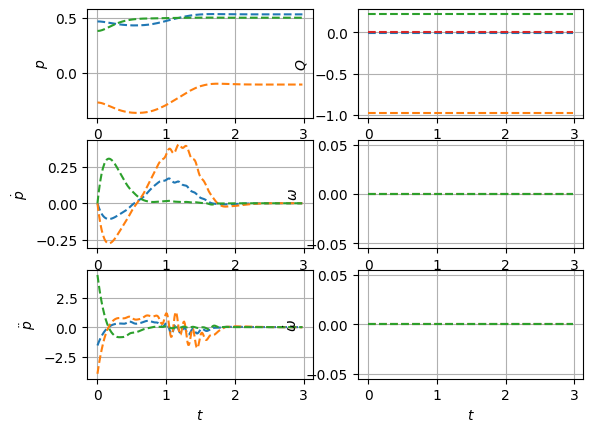

In [94]:
dmp.a_z=30
traj_dec3, t_dec3 = dmp.decode()
xt_dec3 = traj_dec3.copy()
t_dec3 = np.array(t_dec3)

plotctraj(t=t_dec3, xt=xt_dec3, linestyle="--")

plt.show()

In [95]:
r.CMove(xt_dec[0],5)
r.CPath(path=xt_dec,t=t_dec)
r.CMove(xt_dec2[0],5)
r.CPath(path=xt_dec2,t=t_dec2)
r.CMove(xt_dec3[0],5)
r.CPath(path=xt_dec3,t=t_dec3)

0

**17. Poskusite spremeniti tudi čas izvajanja ter potem hkrati čas in cilj. Narišite te trajektorije ter jih tudi izvedite.**

In [96]:
dmp.tau

2.990020685829222

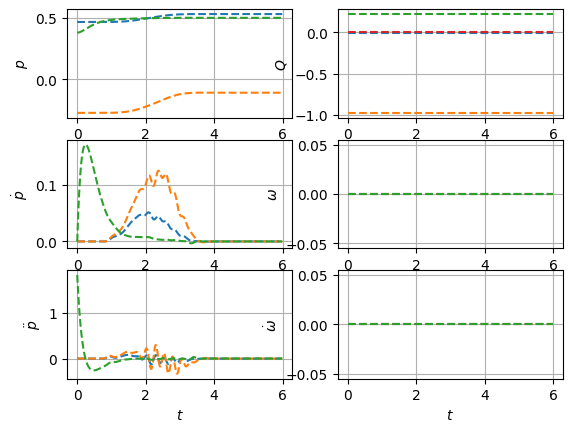

In [98]:
dmp.tau=6
dmp.a_z=48.0
traj_dec4, t_dec4 = dmp.decode()
xt_dec4 = traj_dec4.copy()
t_dec4 = np.array(t_dec4)

plotctraj(t=t_dec4, xt=xt_dec4, linestyle="--")

plt.show()

In [99]:
r.CMove(xt_dec[0],5)
r.CPath(path=xt_dec,t=t_dec)
r.CMove(xt_dec2[0],3)
r.CPath(path=xt_dec2,t=t_dec2)
r.CMove(xt_dec3[0],3)
r.CPath(path=xt_dec3,t=t_dec3)
r.CMove(xt_dec4[0],3)
r.CPath(path=xt_dec4,t=t_dec4)

0

**18. Narišite družino trajektorij, kjer se g spreminja, npr po 5 cm, od 0 do 30 cm.**

In [106]:
np.linspace(0,0.3,7)

array([ 0.0000,  0.0500,  0.1000,  0.1500,  0.2000,  0.2500,  0.3000])

In [145]:
dmp.a_z

48.0

In [149]:
goals= np.linspace(0,0.3,7)
trajektorije=[]
for g in goals:
    dmp.goal+=0.05
    traj,t = dmp.decode()
    trajektorije.append(traj)
    
    





In [150]:
r.CMove(trajektorije[0][0],3)

0

**19. Izvedite te trajektorije.**

In [138]:
round(t[-1])

6

In [146]:
r.ErrorRecovery()

Panda::Recovering from errors:
 ['joint_velocity_violation']
Panda::Attempting to change robot mode from 4


0

In [151]:
xt_dec=trajektorije[0]    
r.CMove(xt_dec[0],3)
r.CPath(path=xt_dec,t=t)

0

In [152]:
for i in range(0,round(t[-1])):
    xt_dec=trajektorije[i]    
    r.CMove(xt_dec[0],3)
    r.CPath(path=xt_dec,t=t)